In [1472]:
# Need an older version of numba-cuda for the T4, restart after running this
# !pip install numba-cuda==0.4.0

# Setup (Includes Settings)

In [1473]:
import numpy as np, matplotlib.pyplot as plt, math
from numba import cuda
from matplotlib.axes import Axes

from typing import List, Tuple
from numba.cuda.cudadrv.devicearray import DeviceNDArray
from numba.types import float32, int32

import matplotlib.animation as animation
from IPython.display import HTML

# Not sure what this does but it makes things not break do not touch this
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

In [1474]:
# Settings
nbirds: int = 32

# Containers of box
amount_of_space: int = 32

type_colors: List[str] = ['yellow', 'blue', 'green', 'purple'] # , 'orange', 'magenta', 'pink', 'red', 'cyan', 'brown', 'lime', 'navy', 'maroon', 'olive', 'teal', 'silver', 'gold', 'indigo', 'coral', 'salmon'] # <-- Heheheha

# Number of flocks, add more colors if making more flocks
nflocks: int = len(type_colors)

print(f"""
{nbirds=}
{nflocks=}
""")

# This is a gpu architecture thing based on how I implemented this
# Don't change this unless you are very confident
MAX_BIRDS_PER_FLOCK: int = 32


nbirds=32
nflocks=4



# Utils

In [1475]:
def plot_birds(
    positions: np.ndarray,
    species: np.ndarray,
    directions: np.ndarray,
    bird_size: int = 20,
    arrow_width: int = 4e-3,
    ax = None,
  ) -> Axes:

  if ax == None:

    fig, ax = plt.subplots()

  # Show birds
  ax.scatter(
      *positions.T,
      color=[type_colors[i] for i in species.flat],
      s=bird_size,
  )

  # Show direction
  ax.quiver(
      *positions.T,
      *directions.T,
      color='red',
      width=arrow_width,

  )

  # Make it cleaner
  ax.set_xticks([])
  ax.set_yticks([])

  return ax

### Numba Utils (Most things aren't supported)

In [1476]:
@cuda.reduce
def reduce_sum(a, b) -> float:
  return a + b

@cuda.jit(device=True)
def kernel_sum(a: Tuple) -> float:
  i: float =  0

  for ai in a:

    i += ai

  return i

@cuda.jit(device=True)
def kernel_prod(a: Tuple) -> float:
  i: float = 1

  for ai in a:

    i *= ai

  return i

@cuda.jit(device=True)
def kernel_dot(a: Tuple, b: Tuple) -> float:
  i: float = 0

  for ai, bi in zip(a, b):

    i += ai * bi

  return i

@cuda.jit(device=True)
def kernel_norm(a: Tuple) -> float:
  i: float = 0

  for ai in a:

    i += ai ** 2

  return math.sqrt(i)

@cuda.jit(device=True)
def kernel_elem_add_2d(a: Tuple, b: Tuple) -> Tuple:

  one = a[0] + b[0]
  two = a[1] + b[1]

  return (one, two)

@cuda.jit(device=True)
def kernel_elem_sub_2d(a: Tuple, b: Tuple) -> Tuple:

  one = a[0] - b[0]
  two = a[1] - b[1]

  return (one, two)

@cuda.jit(device=True)
def kernel_elem_mult_2d(a: Tuple, b: Tuple) -> Tuple:

  one = a[0] * b[0]
  two = a[1] * b[1]

  return (one, two)

@cuda.jit(device=True)
def kernel_negative_2d(a: Tuple) -> Tuple:

  one = -a[0]
  two = -a[1]

  return (one, two)


@cuda.jit(device=True)
def cosine_similarity(a: Tuple, b: Tuple) -> float:
  norm_a = kernel_norm(a)
  norm_b = kernel_norm(b)

  if norm_a < 1e-8 or norm_b < 1e-8:
    return 0.0

  return kernel_sum(kernel_elem_mult_2d(a, b)) / (norm_a * norm_b)

@cuda.jit(device=True)
def euclidean_distance(
    a: Tuple,
    b: Tuple,
) -> float:

  return kernel_norm(kernel_elem_sub_2d(a, b))

@cuda.jit(device=True)
def unit_vector_2d(
    a: Tuple,
) -> float:

  norm: float = kernel_norm(a)

  if norm < 1e-8:
    return (0.0, 0.0)

  return kernel_elem_mult_2d(a, (1 / norm, 1 / norm))

# Generate a Flock

In [1477]:
positions: np.ndarray = np.random.uniform(
    low=0,
    high=amount_of_space,
    size=(nbirds, 2)
)

species: np.ndarray = np.random.randint(
    low=0,
    high=nflocks,
    size=(nbirds, 1)
)

# 2D Vectors that specify direction and velocity
# Initialize normally
directions: np.ndarray = np.random.normal(
    # Mean
    loc=0.0,
    # STD
    scale=1.0,
    size=(nbirds, 2),
)

# So we don't accidentally exceed the limit
flock_counter = np.unique(species.T[0], return_counts=True)

if any([count > MAX_BIRDS_PER_FLOCK for value, count in zip(*flock_counter)]):

  # Offending number of birds in the flock
  too_many_birds = flock_counter[1].max()

  raise Exception(f'A flock of birds (n={too_many_birds}) has more birds than limit {MAX_BIRDS_PER_FLOCK}')

# To go back from gpu format
def from_gpu_format(a: np.ndarray) -> np.ndarray:
  # take (nflock, MAX+B_P_F, 2) -> (nbirds, 2)
  regular_format = None

  for nf in range(nflocks):

    nbirds: int = flock_counter[1][nf]

    real_birds = a[nf, 0: nbirds]

    if regular_format is None:

      regular_format = real_birds

    else:

      regular_format = np.vstack([regular_format, real_birds])

  return regular_format

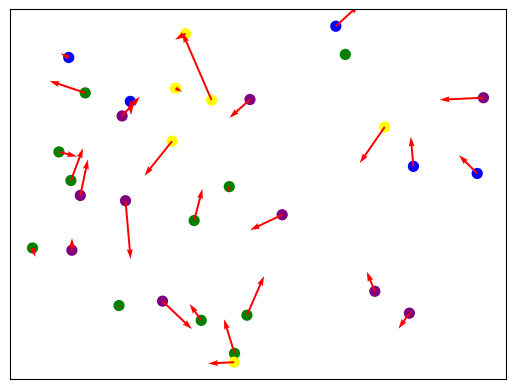

In [1478]:
# Look at our birds
plot_birds(positions, species, directions, bird_size=50)
pass

In [1479]:
# make flocks into indexable list for gpu, must be a set shape or it is weird
flock_positions: np.ndarray = np.zeros((nflocks, MAX_BIRDS_PER_FLOCK, 2))
flock_directions: np.ndarray = np.zeros((nflocks, MAX_BIRDS_PER_FLOCK, 2))

flock_counts: np.ndarray = flock_counter[1].astype(np.int32)

for f in range(nflocks):

  n: int = flock_counts[f]

  flock_positions[f, 0: n] = positions[(species == f)[:, 0]]
  flock_directions[f, 0: n] = directions[(species == f)[:, 0]]

# Flocking Logic

### Basically Boids but with bird types

In [1480]:
# For alignment
@cuda.jit(device=True)
def alignment(
    e_position: Tuple,
    b_position: Tuple,
    e_direction: Tuple,
    b_direction: Tuple,
) -> Tuple:

  # Only have an effect if with in a reasonable distance
  if euclidean_distance(e_position, b_position) < 8:

    # Get the cosine similarity, scale down so doesn't explode
    cos_sim_score: float = cosine_similarity(e_direction, b_direction)

    # weighted direction by cosine similarity?
    return unit_vector_2d(b_direction) # kernel_elem_mult_2d(unit_vector_2d(b_direction), (cos_sim_score, cos_sim_score))

  # If not return zeros
  return (0.0, 0.0)

# For collision avoidance
@cuda.jit(device=True)
def collision_avoidance(
    e_position: Tuple,
    b_position: Tuple,
    e_direction: Tuple,
    b_direction: Tuple,
) -> Tuple:

  # If we are within a certain range
  # Find if in range say 8
  if euclidean_distance(e_position, b_position) < 8:
        return unit_vector_2d(kernel_elem_sub_2d(e_position, b_position))
  return (0.0, 0.0)

# For center, because we do all of them we can do an implicit mean
@cuda.jit(device=True)
def huddle(
    e_position: Tuple,
    b_position: Tuple,
) -> Tuple:

    distance = euclidean_distance(e_position, b_position)

    # Make alignment narrow because they tend to chain and run into walls :(
    if distance < 15 and distance > 8:  # Only huddle in middle range

        direction = kernel_elem_sub_2d(b_position, e_position)
        return unit_vector_2d(direction)

    return (0.0, 0.0)

In [1481]:
@cuda.jit
def flock_logic(
  # Store arrays for flocks so we can retrieve them
  # Both (nflocks, MAX_NUMBER_BIRDS_PER_FLOCK, nflocks * MAX_NUMBER_OF_BIRDS, 2)
  # Non existant birds should be zero for everything
  # Use flock numbers to limit
  flock_positions: DeviceNDArray,
  flock_directions: DeviceNDArray,

  # Our output arrays
  new_directions: DeviceNDArray,

  # So we don't attempt to acsess memory that does not exist
  # (nflocks, 1)
  flock_numbers: DeviceNDArray,

  # For house keeping, don't go outside of this number
  nflocks: int,

) -> None:

  # Flock effected and by are in grid ids
  effected_flock_id = cuda.blockIdx.x
  by_flock_id = cuda.blockIdx.y

  # If we are within a flock
  same_flock: bool = effected_flock_id == by_flock_id

  # Don't run if these is an invalid id
  if nflocks <= effected_flock_id or nflocks <= by_flock_id:
    return

  # Load number of birds for flocks
  effetced_numbers: int = flock_numbers[effected_flock_id]
  by_numbers: int = flock_numbers[by_flock_id]

  # Get birds in question ids
  effected_bird_id = cuda.threadIdx.x
  by_bird_id = cuda.threadIdx.y

  # If either bird does not exit
  if effetced_numbers <= effected_bird_id or by_numbers <= by_bird_id:
    return

  # If same block id and same bird id its the same bird!
  if same_flock and effected_bird_id == by_bird_id:
    # Bird cannot interact with itself
    return

  # Get data for birds
  effetced_bird_position = flock_positions[effected_flock_id, effected_bird_id]
  effetced_bird_direction = flock_directions[effected_flock_id, effected_bird_id]

  by_bird_position = flock_positions[by_flock_id, by_bird_id]
  by_bird_direction = flock_directions[by_flock_id, by_bird_id]

  # Convert to tuples, bc DeviceNDArray basically only support indexing
  effetced_bird_position = (effetced_bird_position[0], effetced_bird_position[1])
  effetced_bird_direction = (effetced_bird_direction[0], effetced_bird_direction[1])

  by_bird_position = (by_bird_position[0], by_bird_position[1])
  by_bird_direction = (by_bird_direction[0], by_bird_direction[1])

  # Calculate new scores to find new direction
  a = alignment(
      effetced_bird_position,
      by_bird_position,
      effetced_bird_direction,
      by_bird_direction,
  )
  h = huddle(
      effetced_bird_position,
      by_bird_position
  )

  c = collision_avoidance(
      effetced_bird_position,
      by_bird_position,
      effetced_bird_direction,
      by_bird_direction,
  )

  if same_flock:
    # Draw in
    new_directions[effected_flock_id, effected_bird_id, by_flock_id * MAX_BIRDS_PER_FLOCK + by_bird_id] = \
      kernel_elem_add_2d(
          kernel_elem_mult_2d(a, (0.05, 0.05)),
          kernel_elem_add_2d(
              kernel_elem_mult_2d(c, (0.7, 0.7)), kernel_elem_mult_2d(h, (0.2, 0.2))
          )
      )

  else:
    # Repel -a - h + c
    new_directions[effected_flock_id, effected_bird_id, by_flock_id * MAX_BIRDS_PER_FLOCK + by_bird_id] = \
      kernel_elem_add_2d(
          kernel_negative_2d(kernel_elem_mult_2d(a, (0.05, 0.05))),
          kernel_elem_add_2d(
              kernel_elem_mult_2d(c, (0.7, 0.7)), kernel_negative_2d(kernel_elem_mult_2d(h, (0.4, 0.4)))
          )
      )

In [1482]:
blocks_per_grid = (nflocks, nflocks)
threads_per_block = (MAX_BIRDS_PER_FLOCK, MAX_BIRDS_PER_FLOCK)

print(blocks_per_grid, threads_per_block)

flock_positions = cuda.to_device(flock_positions)
flock_directions = cuda.to_device(flock_directions)

# nflocks* MAX_BIRDS_PER_FLOCK = total number of birds or max number of contributions
new_directions = cuda.device_array(shape=[nflocks, MAX_BIRDS_PER_FLOCK, nflocks* MAX_BIRDS_PER_FLOCK, 2])

flock_counts = cuda.to_device(flock_counts)

flock_logic[blocks_per_grid, threads_per_block](
    flock_positions,
    flock_directions,

    new_directions,

    flock_counts,

    nflocks,
)

(4, 4) (32, 32)


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:605: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


# Putting it Toghether

In [1483]:
frames: int = 600

In [1484]:
@cuda.jit
def move_positions(
  flock_positions: DeviceNDArray,
  old_directions: DeviceNDArray,
  new_directions: DeviceNDArray,

  # Our output arrays
  new_positions: DeviceNDArray,

  # For passing on to next cycle
  refined_directions: DeviceNDArray,

  # So we don't attempt to acsess memory that does not exist
  # (nflocks, 1)
  flock_counts: DeviceNDArray,

  # For house keeping, don't go outside of this number
  nflocks: int,

  # So our birds dont go out of bounds
  amount_of_space: int,
) -> None:

  # func[(nflocks), (MAX_B_P_F)]
  flock_id = cuda.blockIdx.x
  bird_id = cuda.threadIdx.x

  # Flock does not exist
  if nflocks <= flock_id:
    return

  # Get our number of birds in this flock
  flock_members: int = flock_counts[flock_id]

  # Bird is not in flock
  if flock_members <= bird_id:
    return

  # Get our contributions
  contributions = new_directions[flock_id, bird_id]

  non_zero_contributions: int = 0

  direction = (0.0, 0.0)

  for c in contributions:

    # Check if it is real
    if c[0] != 0 or c[1] != 0:

      non_zero_contributions += 1

      direction = kernel_elem_add_2d(direction, c)

  # If alone teleport to center
  if non_zero_contributions == 0:
    # Throw in center
    refined_directions[flock_id, bird_id] = (0.0, 0.0)
    new_positions[flock_id, bird_id] = (amount_of_space // 2, amount_of_space // 2)
    return

  bird_position = flock_positions[flock_id, bird_id]
  bird_old_direction = old_directions[flock_id, bird_id]

  # Make into a Tuple
  bird_position = (bird_position[0], bird_position[1])
  bird_old_direction = (bird_old_direction[0], bird_old_direction[1])

  # Add smoothing from old direction to new
  direction = unit_vector_2d(
      kernel_elem_add_2d(
          kernel_elem_mult_2d(
              direction, (0.4, 0.4)
          ),
          kernel_elem_mult_2d(
              bird_old_direction, (0.6, 0.6)
          )
      )
  )

  refined_directions[flock_id, bird_id] = direction

  move_to = kernel_elem_add_2d(bird_position, direction)

  # Check if out of bounds and update position
  wall_buffer: int = 0

  # If out of bounds move to center
  if (amount_of_space - wall_buffer) <= move_to[0] <= wall_buffer or \
      (amount_of_space - wall_buffer) <= move_to[1] <= wall_buffer:

      # Throw in center
      refined_directions[flock_id, bird_id] = (0.0, 0.0)
      new_positions[flock_id, bird_id] = (amount_of_space // 2, amount_of_space // 2)
      return

  # Else do your thing
  new_positions[flock_id, bird_id] = move_to

In [1485]:
# Copied from last section of # Flocking Logic
blocks_per_grid = (nflocks, nflocks)
threads_per_block = (MAX_BIRDS_PER_FLOCK, MAX_BIRDS_PER_FLOCK)

flock_positions = cuda.to_device(flock_positions)
flock_directions = cuda.to_device(flock_directions)

flock_counts = cuda.to_device(flock_counts)

# Store values for video
positions_store = [flock_positions.copy_to_host()]
directions_store = [flock_directions.copy_to_host()]

for f in range(frames):

  new_directions = cuda.device_array(shape=[nflocks, MAX_BIRDS_PER_FLOCK, nflocks* MAX_BIRDS_PER_FLOCK, 2])
  new_positions = cuda.device_array_like(flock_positions)
  refined_directions = cuda.device_array_like(flock_positions)
  # Blank them so doesn't acsess old values
  new_positions[:] = 0.0
  refined_directions[:] = 0.0

  # Compute new directions
  flock_logic[blocks_per_grid, threads_per_block](
    flock_positions,
    flock_directions,

    new_directions,

    flock_counts,

    nflocks,
  )

  move_positions[nflocks, MAX_BIRDS_PER_FLOCK](
    flock_positions,
    flock_directions,
    new_directions,

    new_positions,
    refined_directions,

    flock_counts,

    nflocks,
    amount_of_space,
  )

  positions_store.append(new_positions.copy_to_host())
  directions_store.append(refined_directions.copy_to_host())

  flock_positions = new_positions
  flock_directions = refined_directions

positions_store = np.array(positions_store)
directions_store = np.array(directions_store)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:605: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:605: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:605: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Generating video...


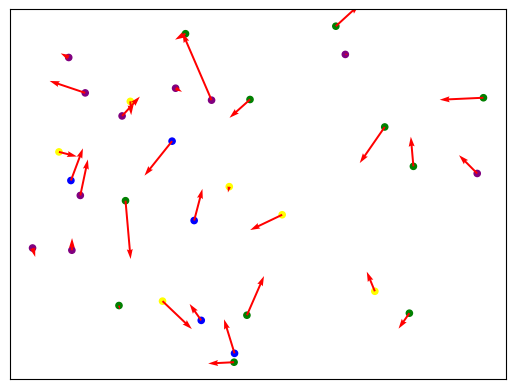

In [1486]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()

def animate(frame, ax, positions_store, directions_store, species):
    ax.clear()
    ax = plot_birds(
      from_gpu_format(positions_store[frame]),
      species,
      from_gpu_format(directions_store[frame]),
      ax = ax
    )
    return ax.collections + ax.patches  # artists that FuncAnimation can redraw

ani = FuncAnimation(
    fig,
    animate,
    frames=len(positions_store),
    fargs=(ax, positions_store, directions_store, species),
    interval=50,
)

# This takes a while
print('Generating video...')
HTML(ani.to_html5_video())